# Taller 2
1. Hacer un programa que lea una imagen en escala de grises y
produzca el histograma correspondiente.

2. Hacer un programa que cargue una imagen a color y
produzca el histograma con las líneas de colores RGB.

3. Cargar una imagen en escala de grises y hacer una función
que ponga en un vector de 256 posiciones, los valores de
frecuencias de pixels, usando ciclos para recorrer la imagen.

4. Hacer el Histograma correspondiente con el vector del
ejercicio enterior.

5. Hacer lo mismo de los dos puntos anteriores con cada capa de
una imagen en formato RGB.

In [74]:
import cv2
import matplotlib.pyplot as plt
import os

1. Hacer un programa que lea una imagen en escala de grises y
produzca el histograma correspondiente.

Tamaño de la imagen: (533, 800)
Cantidad de píxeles: 426400
Suma del histograma: 426400.0


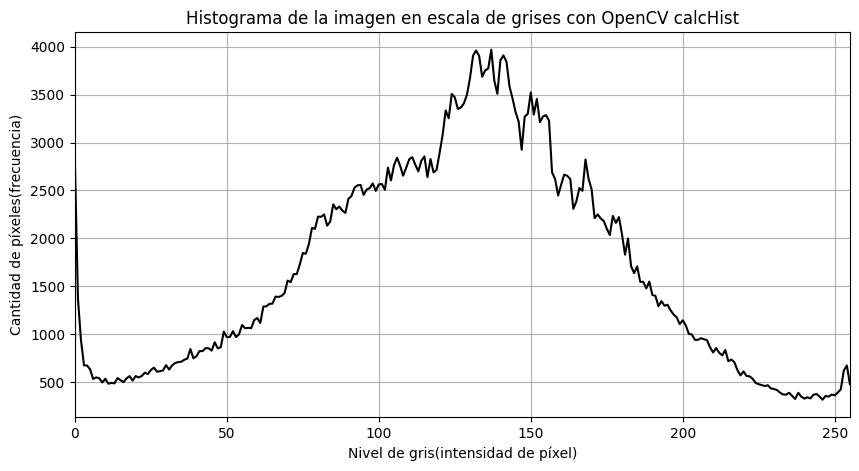

In [75]:
os.makedirs("resultados", exist_ok=True)

imagen_gris = cv2.imread("images/paisaje.png", cv2.IMREAD_GRAYSCALE)
def crear_histograma_opencv(imagen):
    """
    calcHist necesita
    - imagen: lista de imágenes (en este caso solo una)
    - canales: lista de canales a usar (en este caso solo el canal 0)
    - mascara: None (no se usa máscara)
    - histSize: lista con la cantidad de bins o divisiones (en este caso 256)
    - rangos: lista con el rango de valores (intensidades) (en este caso de 0 a 256)
    """
    histograma = cv2.calcHist([imagen], [0], None, [256], [0, 256])
    return histograma

histograma_opencv = crear_histograma_opencv(imagen_gris)
print("Tamaño de la imagen:", imagen_gris.shape)
print("Cantidad de píxeles:", imagen_gris.size)
print("Suma del histograma:", histograma_opencv.sum())


plt.figure(figsize=(10, 5))
plt.plot(range(256), histograma_opencv, color="black")
plt.title("Histograma de la imagen en escala de grises con OpenCV calcHist")
plt.xlabel("Nivel de gris(intensidad de píxel)")
plt.ylabel("Cantidad de píxeles(frecuencia)")
plt.xlim(0, 255)
plt.grid()
plt.savefig("resultados/histogramapt1.png")
plt.show()

2. Hacer un programa que cargue una imagen a color y
produzca el histograma con las líneas de colores RGB.

Total del canal Blue: 426400
Total del canal Green: 426400
Total del canal Red: 426400
Tamaño de la imagen: (533, 800, 3)
Cantidad de píxeles: 426400
Cantidad total de valores BGR: 1279200


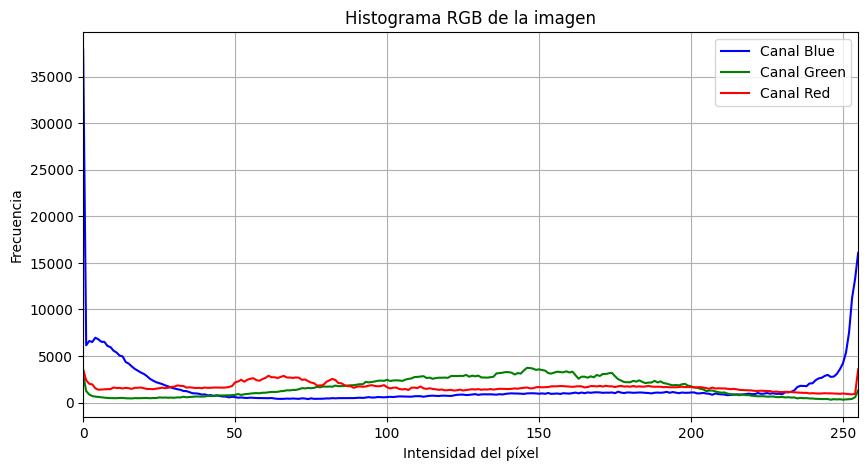

In [76]:
imagen_color = cv2.imread("images/paisaje.png", cv2.IMREAD_COLOR)

canales = {
  "0": "Blue",
  "1": "Green",
  "2": "Red"
}

plt.figure(figsize=(10, 5))# Tamaño de la figura
for indice, color in canales.items():
    # Calcular el histograma para cada canal de color
    histograma_color = cv2.calcHist([imagen_color], [int(indice)], None, [256], [0, 256])

    plt.plot(histograma_color, color=color.lower(), label=f"Canal {color}")

    print(f"Total del canal {color}:",  int(histograma_color.sum()))


alto, ancho, canales_img = imagen_color.shape
print("Tamaño de la imagen:", imagen_color.shape)
print("Cantidad de píxeles:", alto * ancho)
print("Cantidad total de valores BGR:", imagen_color.size)

plt.title("Histograma RGB de la imagen")
plt.xlabel("Intensidad del píxel")
plt.ylabel("Frecuencia")
plt.xlim(0, 255)
plt.legend()
plt.grid()
plt.savefig("resultados/histogramacolorpt2.png")
plt.show()


3. Cargar una imagen en escala de grises y hacer una función
que ponga en un vector de 256 posiciones, los valores de
frecuencias de pixels, usando ciclos para recorrer la imagen.

4. Hacer el Histograma correspondiente con el vector del
ejercicio enterior.

Tamaño de la imagen: (533, 800)
Cantidad de posiciones: 256
Suma de frecuencias: 426400
Cantidad de píxeles: 426400


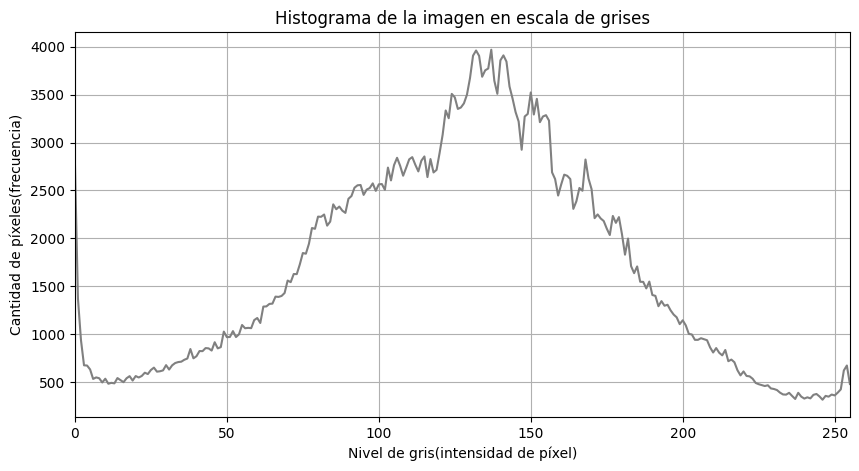

In [77]:
imagen = cv2.imread("images/paisaje.png", cv2.IMREAD_GRAYSCALE)

histograma = [0] * 256  # Inicializamos el histograma con 256 ceros

filas, columnas = imagen.shape
for i in range(filas):
    for j in range(columnas):
        nivel_gris = int(imagen[i,j])
        histograma[nivel_gris] += 1  # Incrementamos el contador del nivel de gris correspondiente

print("Tamaño de la imagen:", imagen.shape)
print("Cantidad de posiciones:", len(histograma))
print("Suma de frecuencias:", sum(histograma))
print("Cantidad de píxeles:", imagen.size)

plt.figure(figsize=(10, 5))
plt.plot(range(256), histograma, color="gray")
plt.title("Histograma de la imagen en escala de grises")
plt.xlabel("Nivel de gris(intensidad de píxel)")
plt.ylabel("Cantidad de píxeles(frecuencia)")
plt.xlim(0, 255)
plt.grid()
plt.savefig("resultados/histogramapt3y4.png")
plt.show()


5. Hacer lo mismo de los dos puntos anteriores con cada capa de
una imagen en formato RGB.

Tamaño de la imagen: (533, 800, 3)
Azul: 426400
Verde: 426400
Rojo: 426400
Cantidad de píxeles: 426400


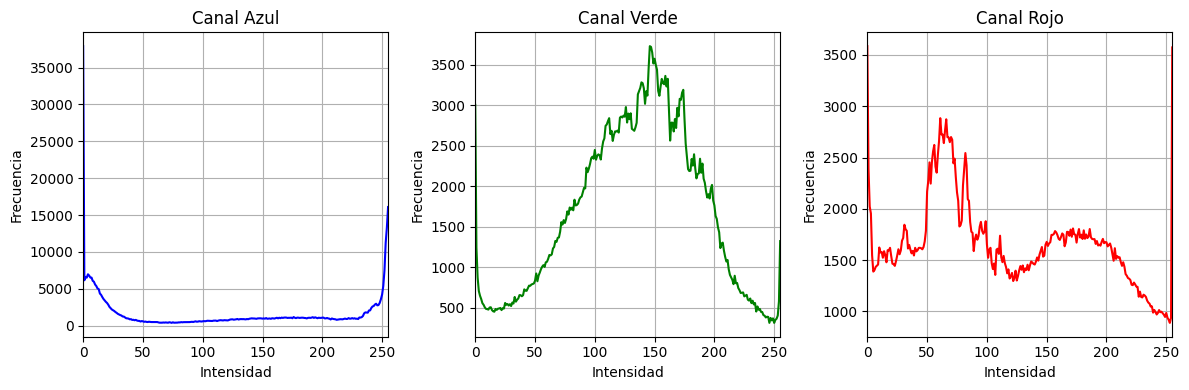

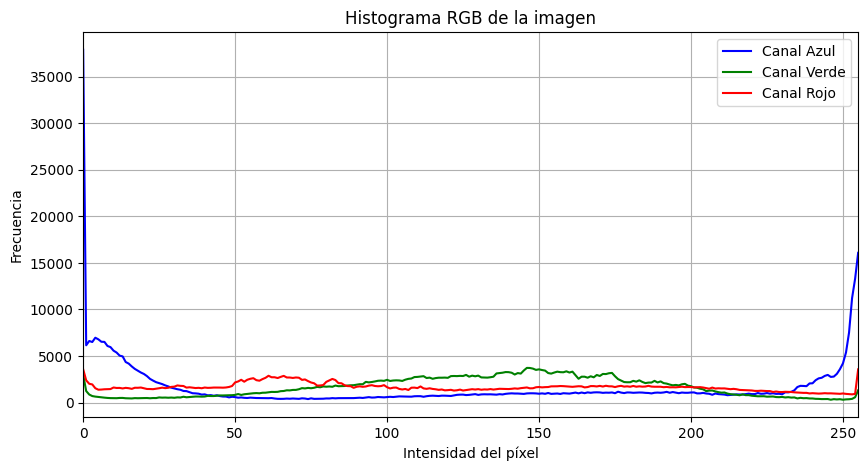

In [78]:
#Carga de la imagen en color
imagen_color = cv2.imread("images/paisaje.png", cv2.IMREAD_COLOR)

#Como tenemos 3 canales colores BGR creamos un histograma para cada canal de color
histograma_blue = [0] * 256
histograma_green = [0] * 256
histograma_red = [0] * 256

filas, columnas, canales_img = imagen_color.shape

for fila in range(filas):
    for columna in range(columnas):
        #Obtenemos el pixel en la posición (fila, columna) que contiene los valores de los 3 canales de color (BGR)
        pixel = imagen_color[fila, columna]
        #Incrementamos el histograma correspondiente a cada canal de color
        histograma_blue[pixel[0]] += 1
        histograma_green[pixel[1]] += 1
        histograma_red[pixel[2]] += 1

print("Tamaño de la imagen:", imagen_color.shape)
print("Azul:", sum(histograma_blue))
print("Verde:", sum(histograma_green))
print("Rojo:", sum(histograma_red))
print("Cantidad de píxeles:", filas * columnas)


#Grafica de los histogramas de cada canal de color por separado
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(range(256), histograma_blue, color="blue")
axes[0].set_title("Canal Azul")
axes[0].set_xlabel("Intensidad")
axes[0].set_ylabel("Frecuencia")
axes[0].set_xlim(0, 255)
axes[0].grid()

axes[1].plot(range(256), histograma_green, color="green")
axes[1].set_title("Canal Verde")
axes[1].set_xlabel("Intensidad")
axes[1].set_ylabel("Frecuencia")
axes[1].set_xlim(0, 255)
axes[1].grid()

axes[2].plot(range(256), histograma_red, color="red")
axes[2].set_title("Canal Rojo")
axes[2].set_xlabel("Intensidad")
axes[2].set_ylabel("Frecuencia")
axes[2].set_xlim(0, 255)
axes[2].grid()

plt.tight_layout()
plt.savefig("resultados/histogramas_horizontal.png")
plt.show()



#Grafica de los histogramas de cada canal de color
plt.figure(figsize=(10, 5))

plt.plot(range(256), histograma_blue, color="blue", label="Canal Azul")
plt.plot(range(256), histograma_green, color="green", label="Canal Verde")
plt.plot(range(256), histograma_red, color="red", label="Canal Rojo")
plt.title("Histograma RGB de la imagen")
plt.xlabel("Intensidad del píxel")
plt.ylabel("Frecuencia")
plt.xlim(0, 255)
plt.legend()
plt.grid()
plt.savefig("resultados/histogramacolorpt5.png")
plt.show()

